# Python & Google Colab Primer

## From Public Health Data to Research-Ready Tables

A hands-on practice to get started with Python in Google Colab for reading, inspecting, transforming, visualizing, and exporting public-health data.


## Python primer

Start with the logic. Libraries come after the basic language ideas are clear.

**Activity rhythm:** pause, predict the output, run the try-out code, then compare it with the solution slide.

In [1]:
# Basic values used in a health-data workflow

study_name = "Public Health Data Primer"
report_date = "2021-12-14"
selected_country = "India"

minimum_confirmed_cases = 100_000
high_case_threshold = 1_000_000

print(study_name)
print("Report date:", report_date)
print("Selected country:", selected_country)
print("Minimum cases for rate comparison:", minimum_confirmed_cases)

Public Health Data Primer
Report date: 2021-12-14
Selected country: India
Minimum cases for rate comparison: 100000


In [2]:
# Data types matter because tables contain text, numbers, dates and categories.

print(type(study_name))
print(type(report_date))
print(type(selected_country))
print(type(minimum_confirmed_cases))
print(type(high_case_threshold))

<class 'str'>
<class 'str'>
<class 'str'>
<class 'int'>
<class 'int'>


### Activity 1 —  Understand the datatype

Add the following date in a variable "2020-01-01"  and identify the data type





In [3]:
# Try-out your code here in this cell
Name= ("Houda","neil","Jahanvi")
print(Name[0])


Houda


In [4]:
activity_date = "2020-01-01"

print(activity_date)
print(type(activity_date))

2020-01-01
<class 'str'>


In [5]:
# Lists store repeated items.

core_variables = [
    "Confirmed",
    "Deaths",
    "Recovered",
    "Active"
]

print(core_variables)
print("Number of variables:", len(core_variables))
print("First variable:", core_variables[0])
print("Last variable:", core_variables[-1])

['Confirmed', 'Deaths', 'Recovered', 'Active']
Number of variables: 4
First variable: Confirmed
Last variable: Active


In [6]:
# Dictionaries store meaning.

variable_dictionary = {
    "Confirmed": "Cumulative confirmed cases",
    "Deaths": "Cumulative reported deaths",
    "Recovered": "Reported recoveries",
    "Active": "Reported active cases"
}

print(variable_dictionary["Confirmed"])
print(variable_dictionary["Deaths"])

Cumulative confirmed cases
Cumulative reported deaths


In [7]:
# Loops repeat an action for every item.

for variable in core_variables:
    print("We will inspect:", variable)

We will inspect: Confirmed
We will inspect: Deaths
We will inspect: Recovered
We will inspect: Active


In [8]:
# Conditions convert numbers into interpretable categories.

example_confirmed_cases = 250_000

if example_confirmed_cases >= high_case_threshold:
    print("Very high confirmed-case burden")
elif example_confirmed_cases >= minimum_confirmed_cases:
    print("High confirmed-case burden")
else:
    print("Lower confirmed-case burden")

High confirmed-case burden


In [9]:
# Functions make decisions reusable.

def classify_case_burden(confirmed_cases):
    if confirmed_cases >= 1_000_000:
        return "Very high"
    elif confirmed_cases >= 100_000:
        return "High"
    elif confirmed_cases >= 10_000:
        return "Moderate"
    else:
        return "Low"

print(classify_case_burden(8_500))
print(classify_case_burden(180_000))
print(classify_case_burden(2_500_000))

Low
High
Very high


### Activity 2 — Reuse the decision logic :  Use the classify_case_burden() function

One function can classify many values without rewriting the full decision block.

**Tip:** Predict the category for each number before running the code.

In [10]:
# Try-out the code in this cell

# Activity 2 Try out

confirmed_cases = [600_000, 50, 10_000]

def classify_case_burden(confirmed_cases):
    if confirmed_cases >= 1_000_000:
        return "Very high"
    elif confirmed_cases >= 100_000:
        return "High"
    elif confirmed_cases >= 10_000:
        return "Moderate"
    else:
        return "Low"

for cases in confirmed_cases :
    print(f"{cases:,} cases:", classify_case_burden(cases))

600,000 cases: High
50 cases: Low
10,000 cases: Moderate


## Data-science tools

Now the language basics connect to the common Python data stack.


In [11]:
# Colab usually includes these libraries.
# Run the next line only if an import fails.
# !pip -q install numpy pandas matplotlib seaborn

import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 80)

# Presentation-safe colours
# Blue/teal = neutral data and trust | Red/coral = risk or alert | Diverging palettes = correlation
PRIMARY_BLUE = "#2A6F97"
DARK_TEAL = "#264653"
ALERT_RED = "#D62828"
CORAL = "#E76F51"
DIVERGING_CMAP = "RdBu_r"

print("Python:", sys.version.split()[0])
print("NumPy:", np.__version__)
print("pandas:", pd.__version__)
print("Ready for analysis")


Python: 3.14.6
NumPy: 2.4.4
pandas: 3.0.3
Ready for analysis


# Case-study data
# Extraction of Data

Centre for Systems Science and Engineering, Johns Hopkins University is providing a github repository with all recent data: https://github.com/CSSEGISandData/COVID-19.git


In [12]:
# Keep the data source in one place for reproducibility.

DATA_URL = "https://raw.githubusercontent.com/CSSEGISandData/COVID-19/master/csse_covid_19_data/csse_covid_19_daily_reports/12-14-2021.csv"

# Optional offline route:
# Upload the same CSV to Colab and set LOCAL_BACKUP_CSV = "/content/12-14-2021.csv"
LOCAL_BACKUP_CSV = ""

try:
    raw_df = pd.read_csv(DATA_URL)
    data_source_used = DATA_URL
except Exception as error:
    if LOCAL_BACKUP_CSV:
        raw_df = pd.read_csv(LOCAL_BACKUP_CSV)
        data_source_used = LOCAL_BACKUP_CSV
    else:
        raise RuntimeError(
            "Dataset could not be loaded from the URL. "
            "Upload a CSV to Colab and set LOCAL_BACKUP_CSV."
        ) from error

print("Data source used:")
print(data_source_used)
print("Rows and columns:", raw_df.shape)

raw_df.head()

Data source used:
https://raw.githubusercontent.com/CSSEGISandData/COVID-19/master/csse_covid_19_data/csse_covid_19_daily_reports/12-14-2021.csv
Rows and columns: (4016, 14)


,FIPS,Admin2,Province_State,Country_Region,Last_Update,Lat,Long_,Confirmed,Deaths,Recovered,Active,Combined_Key,Incident_Rate,Case_Fatality_Ratio
0,NaN,NaN,NaN,Afghanistan,2021-12-15 03:22:16,33.93911,67.709953,157660,7329,NaN,NaN,Afghanistan,405.000562,4.648611
1,NaN,NaN,NaN,Albania,2021-12-15 03:22:16,41.15330,20.168300,204301,3144,NaN,NaN,Albania,7099.207728,1.538906
2,NaN,NaN,NaN,Algeria,2021-12-15 03:22:16,28.03390,1.659600,213288,6155,NaN,NaN,Algeria,486.392080,2.885769
3,NaN,NaN,NaN,Andorra,2021-12-15 03:22:16,42.50630,1.521800,20136,134,NaN,NaN,Andorra,26060.959037,0.665475
4,NaN,NaN,NaN,Angola,2021-12-15 03:22:16,-11.20270,17.873900,65431,1737,NaN,NaN,Angola,199.082537,2.654705


## First inspection

Before analysis, check what the table contains.


In [13]:
print("Rows:", raw_df.shape[0])
print("Columns:", raw_df.shape[1])

print("\nColumn names:")
print(list(raw_df.columns))

print("\nTable structure:")
raw_df.info()

Rows: 4016
Columns: 14

Column names:
['FIPS', 'Admin2', 'Province_State', 'Country_Region', 'Last_Update', 'Lat', 'Long_', 'Confirmed', 'Deaths', 'Recovered', 'Active', 'Combined_Key', 'Incident_Rate', 'Case_Fatality_Ratio']

Table structure:
<class 'pandas.DataFrame'>
RangeIndex: 4016 entries, 0 to 4015
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   FIPS                 3268 non-null   float64
 1   Admin2               3272 non-null   str    
 2   Province_State       3837 non-null   str    
 3   Country_Region       4016 non-null   str    
 4   Last_Update          4016 non-null   str    
 5   Lat                  3925 non-null   float64
 6   Long_                3925 non-null   float64
 7   Confirmed            4016 non-null   int64  
 8   Deaths               4016 non-null   int64  
 9   Recovered            10 non-null     float64
 10  Active               10 non-null     float64
 11  Combi

In [14]:
display(raw_df.head(6))
display(raw_df.tail(5))
display(raw_df.describe())

,FIPS,Admin2,Province_State,Country_Region,Last_Update,Lat,Long_,Confirmed,Deaths,Recovered,Active,Combined_Key,Incident_Rate,Case_Fatality_Ratio
0,NaN,NaN,NaN,Afghanistan,2021-12-15 03:22:16,33.93911,67.709953,157660,7329,NaN,NaN,Afghanistan,405.000562,4.648611
1,NaN,NaN,NaN,Albania,2021-12-15 03:22:16,41.15330,20.168300,204301,3144,NaN,NaN,Albania,7099.207728,1.538906
2,NaN,NaN,NaN,Algeria,2021-12-15 03:22:16,28.03390,1.659600,213288,6155,NaN,NaN,Algeria,486.392080,2.885769
3,NaN,NaN,NaN,Andorra,2021-12-15 03:22:16,42.50630,1.521800,20136,134,NaN,NaN,Andorra,26060.959037,0.665475
4,NaN,NaN,NaN,Angola,2021-12-15 03:22:16,-11.20270,17.873900,65431,1737,NaN,NaN,Angola,199.082537,2.654705
5,NaN,NaN,NaN,Antigua and Barbuda,2021-12-15 03:22:16,17.06080,-61.796400,4177,117,NaN,NaN,Antigua and Barbuda,4265.378646,2.801053


,FIPS,Admin2,Province_State,Country_Region,Last_Update,Lat,Long_,Confirmed,Deaths,Recovered,Active,Combined_Key,Incident_Rate,Case_Fatality_Ratio
4011,NaN,NaN,Unknown,Ukraine,2021-12-15 03:22:16,NaN,NaN,0,0,0.0,0.0,"Unknown, Ukraine",0.0,0.0
4012,NaN,NaN,NaN,Nauru,2021-12-15 03:22:16,-0.5228,166.9315,0,0,0.0,0.0,Nauru,0.0,0.0
4013,NaN,NaN,Niue,New Zealand,2021-12-15 03:22:16,-19.0544,-169.8672,0,0,0.0,0.0,"Niue, New Zealand",0.0,0.0
4014,NaN,NaN,NaN,Tuvalu,2021-12-15 03:22:16,-7.1095,177.6493,0,0,0.0,0.0,Tuvalu,0.0,0.0
4015,NaN,NaN,Pitcairn Islands,United Kingdom,2021-12-15 03:22:16,-24.3768,-128.3242,0,0,0.0,0.0,"Pitcairn Islands, United Kingdom",0.0,0.0


,FIPS,Lat,Long_,Confirmed,Deaths,Recovered,Active,Incident_Rate,Case_Fatality_Ratio
count,3268.000000,3925.000000,3925.000000,4.016000e+03,4016.000000,10.0,10.0,3925.000000,3975.000000
mean,32405.943390,35.736183,-71.109728,6.768500e+04,1332.773406,0.0,0.0,14451.603478,2.783604
std,18056.381177,13.441327,55.361480,3.764964e+05,7383.695941,0.0,0.0,5819.647213,45.885740
min,60.000000,-71.949900,-178.116500,0.000000e+00,0.000000,0.0,0.0,0.000000,0.000000
25%,19048.500000,33.191535,-96.595639,1.922250e+03,31.000000,0.0,0.0,11680.911681,1.141195
50%,30068.000000,37.895700,-86.717326,5.412000e+03,89.000000,0.0,0.0,15737.659456,1.615169
75%,47041.500000,42.176955,-77.357900,2.192600e+04,311.000000,0.0,0.0,18220.328486,2.222062
max,99999.000000,71.706900,178.065000,9.275513e+06,154691.000000,0.0,0.0,56770.881086,2764.772727


### Activity 3 — First inspection - Count unique countries in the dataset

Before preprocessing , one useful first question is : how many countries or regions are represented?

**Tip:** Use the original `Country_Region` column from the raw table.

In [15]:
# Try-out your code here in this cell
# Activity 3 Try out

unique_countries = raw_df["Country_Region"].nunique()

print("Unique countries/regions:", unique_countries)


Unique countries/regions: 201


## Prepare an analysis table

The original file is preserved. The analysis table receives cleaner names and controlled numeric fields.


In [16]:
analysis_df = raw_df.copy()
analysis_df.columns = analysis_df.columns.str.strip()

rename_map = {
    "Country_Region": "country",
    "Province_State": "province",
    "Last_Update": "last_update",
    "Lat": "latitude",
    "Long_": "longitude",
    "Confirmed": "confirmed",
    "Deaths": "deaths",
    "Recovered": "recovered",
    "Active": "active",
    "Incident_Rate": "incident_rate",
    "Case_Fatality_Ratio": "case_fatality_ratio",
    "Combined_Key": "combined_key"
}

analysis_df = analysis_df.rename(
    columns={old: new for old, new in rename_map.items() if old in analysis_df.columns}
)

preferred_columns = [
    "country",
    "province",
    "last_update",
    "latitude",
    "longitude",
    "confirmed",
    "deaths",
    "recovered",
    "active",
    "incident_rate",
    "case_fatality_ratio",
    "combined_key"
]

available_columns = [column for column in preferred_columns if column in analysis_df.columns]
analysis_df = analysis_df[available_columns].copy()

analysis_df.head()

,country,province,last_update,latitude,longitude,confirmed,deaths,recovered,active,incident_rate,case_fatality_ratio,combined_key
0,Afghanistan,NaN,2021-12-15 03:22:16,33.93911,67.709953,157660,7329,NaN,NaN,405.000562,4.648611,Afghanistan
1,Albania,NaN,2021-12-15 03:22:16,41.15330,20.168300,204301,3144,NaN,NaN,7099.207728,1.538906,Albania
2,Algeria,NaN,2021-12-15 03:22:16,28.03390,1.659600,213288,6155,NaN,NaN,486.392080,2.885769,Algeria
3,Andorra,NaN,2021-12-15 03:22:16,42.50630,1.521800,20136,134,NaN,NaN,26060.959037,0.665475,Andorra
4,Angola,NaN,2021-12-15 03:22:16,-11.20270,17.873900,65431,1737,NaN,NaN,199.082537,2.654705,Angola


In [17]:
numeric_columns = [
    "latitude",
    "longitude",
    "confirmed",
    "deaths",
    "recovered",
    "active",
    "incident_rate",
    "case_fatality_ratio"
]

for column in numeric_columns:
    if column in analysis_df.columns:
        analysis_df[column] = pd.to_numeric(analysis_df[column], errors="coerce")

if "province" in analysis_df.columns:
    analysis_df["province"] = analysis_df["province"].fillna("Not specified")

analysis_df["country"] = analysis_df["country"].fillna("Unknown")

analysis_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4016 entries, 0 to 4015
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   country              4016 non-null   str    
 1   province             4016 non-null   str    
 2   last_update          4016 non-null   str    
 3   latitude             3925 non-null   float64
 4   longitude            3925 non-null   float64
 5   confirmed            4016 non-null   int64  
 6   deaths               4016 non-null   int64  
 7   recovered            10 non-null     float64
 8   active               10 non-null     float64
 9   incident_rate        3925 non-null   float64
 10  case_fatality_ratio  3975 non-null   float64
 11  combined_key         4016 non-null   str    
dtypes: float64(6), int64(2), str(4)
memory usage: 376.6 KB


## Data quality check

A useful analysis begins by making missingness and basic validity visible.


In [18]:
missing_summary = (
    analysis_df
    .isna()
    .sum()
    .reset_index()
    .rename(columns={"index": "column", 0: "missing_count"})
)

missing_summary["missing_percent"] = (missing_summary["missing_count"] / len(analysis_df) * 100).round(2)
missing_summary = missing_summary.sort_values("missing_count", ascending=False)

missing_summary

,column,missing_count,missing_percent
8,active,4006,99.75
7,recovered,4006,99.75
3,latitude,91,2.27
9,incident_rate,91,2.27
4,longitude,91,2.27
10,case_fatality_ratio,41,1.02
0,country,0,0.00
1,province,0,0.00
2,last_update,0,0.00
5,confirmed,0,0.00


In [19]:
quality_checks = {
    "rows": len(analysis_df),
    "columns": analysis_df.shape[1],
    "duplicate_rows": int(analysis_df.duplicated().sum()),
    "countries": int(analysis_df["country"].nunique()),
    "negative_confirmed_rows": int((analysis_df["confirmed"] < 0).sum()) if "confirmed" in analysis_df else 0,
    "negative_death_rows": int((analysis_df["deaths"] < 0).sum()) if "deaths" in analysis_df else 0
}

quality_checks

{'rows': 4016,
 'columns': 12,
 'duplicate_rows': 0,
 'countries': 201,
 'negative_confirmed_rows': 0,
 'negative_death_rows': 0}

### Activity 4 — Find the quality signal

A strong analysis starts by noticing where the table may be weak.

**Tip:** Use the missingness summary and the quality-check dictionary.

In [20]:
# Activity 4 Try out

highest_missing = missing_summary.head(1)

print("Column with highest missingness:")
display(highest_missing)

print("Duplicate rows:", quality_checks["duplicate_rows"])


Column with highest missingness:


,column,missing_count,missing_percent
8,active,4006,99.75


Duplicate rows: 0


## Create derived research variables

Rates need denominators. Small denominators can produce misleading percentages, so the notebook keeps a minimum-case threshold for rate comparison.


In [21]:
count_columns = ["confirmed", "deaths", "recovered", "active"]

for column in count_columns:
    if column in analysis_df.columns:
        analysis_df[column] = analysis_df[column].fillna(0)

analysis_df["case_fatality_percent"] = np.where(
    analysis_df["confirmed"] > 0,
    (analysis_df["deaths"] / analysis_df["confirmed"]) * 100,
    np.nan
)

analysis_df["active_share_percent"] = np.where(
    analysis_df["confirmed"] > 0,
    (analysis_df["active"] / analysis_df["confirmed"]) * 100,
    np.nan
)

analysis_df["case_burden_class"] = analysis_df["confirmed"].apply(classify_case_burden)

analysis_df[
    ["country", "province", "confirmed", "deaths", "case_fatality_percent", "active_share_percent", "case_burden_class"]
].head(10)

,country,province,confirmed,deaths,case_fatality_percent,active_share_percent,case_burden_class
0,Afghanistan,Not specified,157660,7329,4.648611,0.0,High
1,Albania,Not specified,204301,3144,1.538906,0.0,High
2,Algeria,Not specified,213288,6155,2.885769,0.0,High
3,Andorra,Not specified,20136,134,0.665475,0.0,Moderate
4,Angola,Not specified,65431,1737,2.654705,0.0,Moderate
5,Antigua and Barbuda,Not specified,4177,117,2.801053,0.0,Low
6,Argentina,Not specified,5366522,116826,2.176941,0.0,Very high
7,Armenia,Not specified,342765,7845,2.288740,0.0,High
8,Australia,Australian Capital Territory,2210,15,0.678733,0.0,Low
9,Australia,New South Wales,88595,641,0.723517,0.0,Moderate


## NumPy for numerical thinking

NumPy works well when we need quick numerical summaries from columns.


In [22]:
confirmed_values = analysis_df["confirmed"].to_numpy()
death_values = analysis_df["deaths"].to_numpy()
rate_values = analysis_df["case_fatality_percent"].dropna().to_numpy()

print("Total confirmed cases:", int(np.sum(confirmed_values)))
print("Total reported deaths:", int(np.sum(death_values)))
print("Mean confirmed cases per reporting row:", round(np.mean(confirmed_values), 2))
print("Median case fatality percent:", round(np.median(rate_values), 2))
print("90th percentile confirmed cases:", int(np.percentile(confirmed_values, 90)))

analysis_df["high_burden_row"] = np.where(
    analysis_df["confirmed"] >= minimum_confirmed_cases,
    "Review priority",
    "Routine review"
)

analysis_df[["country", "province", "confirmed", "deaths", "high_burden_row"]].head(10)

Total confirmed cases: 271822960
Total reported deaths: 5352418
Mean confirmed cases per reporting row: 67685.0
Median case fatality percent: 1.62
90th percentile confirmed cases: 97820


,country,province,confirmed,deaths,high_burden_row
0,Afghanistan,Not specified,157660,7329,Review priority
1,Albania,Not specified,204301,3144,Review priority
2,Algeria,Not specified,213288,6155,Review priority
3,Andorra,Not specified,20136,134,Routine review
4,Angola,Not specified,65431,1737,Routine review
5,Antigua and Barbuda,Not specified,4177,117,Routine review
6,Argentina,Not specified,5366522,116826,Review priority
7,Armenia,Not specified,342765,7845,Review priority
8,Australia,Australian Capital Territory,2210,15,Routine review
9,Australia,New South Wales,88595,641,Routine review


### Activity 5 — Read the numerical signal

Mean and median can tell different stories when a dataset is uneven.

**Tip:** Predict whether the mean or median confirmed count will be larger, then run the code.

In [23]:
# Try-out your code here in this cell

# Activity 5 Try out

mean_confirmed = np.mean(confirmed_values)
median_confirmed = np.median(confirmed_values)
p90_confirmed = np.percentile(confirmed_values, 90)

print("Mean confirmed cases:", round(mean_confirmed, 2))
print("Median confirmed cases:", round(median_confirmed, 2))
print("90th percentile confirmed cases:", round(p90_confirmed, 2))

if mean_confirmed > median_confirmed:
    print("Signal: The distribution is right-skewed.")
else:
    print("Signal: The distribution is not strongly right-skewed.")

Mean confirmed cases: 67685.0
Median confirmed cases: 5412.0
90th percentile confirmed cases: 97820.0
Signal: The distribution is right-skewed.


## Country-level summary

The raw dataset may contain multiple rows per country. Grouping creates a cleaner country-level table.


In [24]:
summary_fields = {
    "reporting_units": ("country", "count"),
    "confirmed": ("confirmed", "sum"),
    "deaths": ("deaths", "sum"),
    "recovered": ("recovered", "sum"),
    "active": ("active", "sum")
}

if "incident_rate" in analysis_df.columns:
    summary_fields["mean_incident_rate"] = ("incident_rate", "mean")

country_summary = (
    analysis_df
    .groupby("country", as_index=False)
    .agg(**summary_fields)
)

country_summary["case_fatality_percent"] = np.where(
    country_summary["confirmed"] > 0,
    (country_summary["deaths"] / country_summary["confirmed"]) * 100,
    np.nan
)

country_summary["active_share_percent"] = np.where(
    country_summary["confirmed"] > 0,
    (country_summary["active"] / country_summary["confirmed"]) * 100,
    np.nan
)

country_summary["case_burden_class"] = country_summary["confirmed"].apply(classify_case_burden)
country_summary = country_summary.sort_values("confirmed", ascending=False)

country_summary.head(10)

,country,reporting_units,confirmed,deaths,recovered,active,mean_incident_rate,case_fatality_percent,active_share_percent,case_burden_class
186,US,3279,50289495,800046,0.0,0.0,16232.517437,1.590881,0.0,Very high
80,India,37,34710628,476135,0.0,0.0,4236.699153,1.371727,0.0,Very high
24,Brazil,27,22200629,617254,0.0,0.0,12047.905288,2.780345,0.0,Very high
190,United Kingdom,19,10995158,175638,0.0,0.0,9381.106545,1.597412,0.0,Very high
147,Russia,83,9899139,286023,0.0,0.0,6778.099799,2.889372,0.0,Very high
184,Turkey,1,9080452,79503,0.0,0.0,10768.938196,0.875540,0.0,Very high
63,France,12,8438360,121817,0.0,0.0,10208.494902,1.443610,0.0,Very high
67,Germany,17,6582303,106227,0.0,0.0,7857.451328,1.613827,0.0,Very high
82,Iran,1,6160303,130831,0.0,0.0,7334.309344,2.123775,0.0,Very high
7,Argentina,1,5366522,116826,0.0,0.0,11873.945656,2.176941,0.0,Very high


## Case Study Controls: Select, Filter and Compare Countries

Change the values below and rerun the section.


In [25]:
TOP_N = 10
COUNTRY_TO_VIEW = selected_country
MIN_CONFIRMED_FOR_RATE = minimum_confirmed_cases

top_countries = country_summary.head(TOP_N)

selected_country_summary = country_summary[
    country_summary["country"].eq(COUNTRY_TO_VIEW)
]

rate_comparison_table = (
    country_summary[country_summary["confirmed"] >= MIN_CONFIRMED_FOR_RATE]
    .sort_values("case_fatality_percent", ascending=False)
)

display(top_countries)
print("-" * 100)
display(selected_country_summary)
print("-" * 100)
display(rate_comparison_table.head(10))

,country,reporting_units,confirmed,deaths,recovered,active,mean_incident_rate,case_fatality_percent,active_share_percent,case_burden_class
186,US,3279,50289495,800046,0.0,0.0,16232.517437,1.590881,0.0,Very high
80,India,37,34710628,476135,0.0,0.0,4236.699153,1.371727,0.0,Very high
24,Brazil,27,22200629,617254,0.0,0.0,12047.905288,2.780345,0.0,Very high
190,United Kingdom,19,10995158,175638,0.0,0.0,9381.106545,1.597412,0.0,Very high
147,Russia,83,9899139,286023,0.0,0.0,6778.099799,2.889372,0.0,Very high
184,Turkey,1,9080452,79503,0.0,0.0,10768.938196,0.875540,0.0,Very high
63,France,12,8438360,121817,0.0,0.0,10208.494902,1.443610,0.0,Very high
67,Germany,17,6582303,106227,0.0,0.0,7857.451328,1.613827,0.0,Very high
82,Iran,1,6160303,130831,0.0,0.0,7334.309344,2.123775,0.0,Very high
7,Argentina,1,5366522,116826,0.0,0.0,11873.945656,2.176941,0.0,Very high


----------------------------------------------------------------------------------------------------


,country,reporting_units,confirmed,deaths,recovered,active,mean_incident_rate,case_fatality_percent,active_share_percent,case_burden_class
80,India,37,34710628,476135,0.0,0.0,4236.699153,1.371727,0.0,Very high


----------------------------------------------------------------------------------------------------


,country,reporting_units,confirmed,deaths,recovered,active,mean_incident_rate,case_fatality_percent,active_share_percent,case_burden_class
141,Peru,26,2255318,201848,0.0,0.0,6496.171416,8.949869,0.0,Very high
117,Mexico,33,3918987,296721,0.0,0.0,3110.798681,7.571370,0.0,Very high
53,Ecuador,1,534176,33570,0.0,0.0,3023.608150,6.284446,0.0,High
54,Egypt,1,370819,21155,0.0,0.0,362.360056,5.704940,0.0,High
0,Afghanistan,1,157660,7329,0.0,0.0,405.000562,4.648611,0.0,High
22,Bosnia and Herzegovina,1,282587,13028,0.0,0.0,8613.317118,4.610262,0.0,High
26,Bulgaria,1,718651,29764,0.0,0.0,10342.616226,4.141649,0.0,High
37,China,34,125012,4849,0.0,0.0,11.253621,3.878828,0.0,High
28,Burma,1,527274,19193,0.0,0.0,969.079207,3.640043,0.0,High
140,Paraguay,1,463926,16516,0.0,0.0,6504.368015,3.560051,0.0,High


### Activity 6 — Change the research focus

The same workflow can answer a new question by changing only the focus values.

**Tip:** Keep the variable names unchanged and only modify the values.
Use the exact country name as shown in the dataset. The minimum confirmed cases filter is important because very small case numbers can make percentages look unusually high or misleading.

In [26]:
# Try-out your code here in this cell

# Activity 6 Try out

activity_top_n = 15
activity_country_to_view = "Brazil"
activity_min_confirmed_for_rate = 1_000_000

display_columns = [
    "country",
    "confirmed",
    "deaths",
    "case_fatality_percent"
]

activity_top_countries = (
    country_summary
    .sort_values("confirmed", ascending=False)
    .head(activity_top_n)
    .copy()
)

activity_selected_country = country_summary[
    country_summary["country"]
    .astype(str)
    .str.casefold()
    .eq(activity_country_to_view.casefold())
].copy()

activity_rate_table = (
    country_summary[
        country_summary["confirmed"] >= activity_min_confirmed_for_rate
    ]
    .sort_values("case_fatality_percent", ascending=False)
    .copy()
)

print("Activity TOP_N:", activity_top_n)
print("Activity country:", activity_country_to_view)
print("Activity minimum confirmed cases:", f"{activity_min_confirmed_for_rate:,}")

print("\nTop countries by confirmed cases:")
display(activity_top_countries[display_columns])

print(f"\nSelected country: {activity_country_to_view}")
if activity_selected_country.empty:
    print("Selected country was not found. Check the spelling or country name used in the dataset.")
else:
    display(activity_selected_country[display_columns])

print("\nCountries meeting the minimum confirmed-case threshold, sorted by case fatality percent:")
display(activity_rate_table[display_columns].head(10))

Activity TOP_N: 15
Activity country: Brazil
Activity minimum confirmed cases: 1,000,000

Top countries by confirmed cases:


,country,confirmed,deaths,case_fatality_percent
186,US,50289495,800046,1.590881
80,India,34710628,476135,1.371727
24,Brazil,22200629,617254,2.780345
190,United Kingdom,10995158,175638,1.597412
147,Russia,9899139,286023,2.889372
184,Turkey,9080452,79503,0.875540
63,France,8438360,121817,1.443610
67,Germany,6582303,106227,1.613827
82,Iran,6160303,130831,2.123775
7,Argentina,5366522,116826,2.176941



Selected country: Brazil


,country,confirmed,deaths,case_fatality_percent
24,Brazil,22200629,617254,2.780345



Countries meeting the minimum confirmed-case threshold, sorted by case fatality percent:


,country,confirmed,deaths,case_fatality_percent
141,Peru,2255318,201848,8.949869
117,Mexico,3918987,296721,7.571370
81,Indonesia,4259439,143960,3.379788
146,Romania,1794589,57847,3.223412
78,Hungary,1202514,37079,3.083457
147,Russia,9899139,286023,2.889372
165,South Africa,3204642,90172,2.813793
24,Brazil,22200629,617254,2.780345
188,Ukraine,3746106,97328,2.598111
86,Italy,5258886,135049,2.568015


## Matplotlib figure

A simple figure should answer one question clearly.


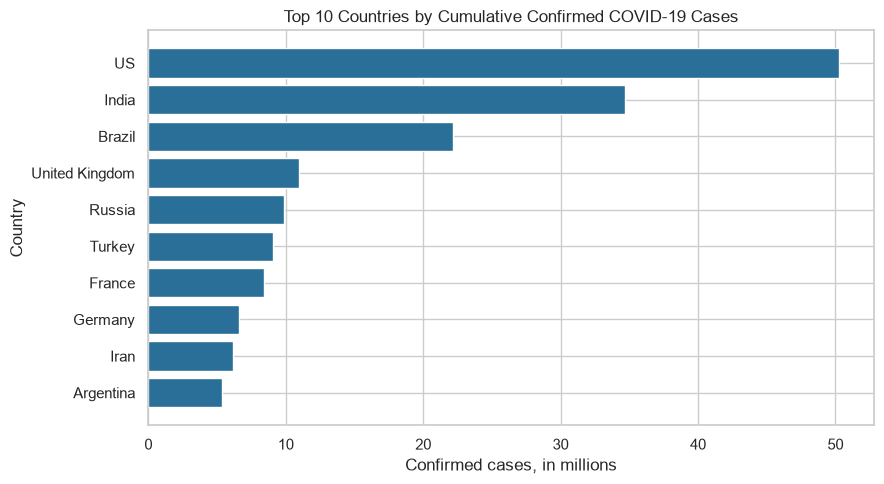

In [27]:
plot_data = top_countries.sort_values("confirmed", ascending=True).copy()
plot_data["confirmed_millions"] = plot_data["confirmed"] / 1_000_000

plt.figure(figsize=(9, 5))

plt.barh(
    plot_data["country"],
    plot_data["confirmed_millions"],
    color=PRIMARY_BLUE
)

plt.title(f"Top {TOP_N} Countries by Cumulative Confirmed COVID-19 Cases")
plt.xlabel("Confirmed cases, in millions")
plt.ylabel("Country")
plt.tight_layout()
plt.show()


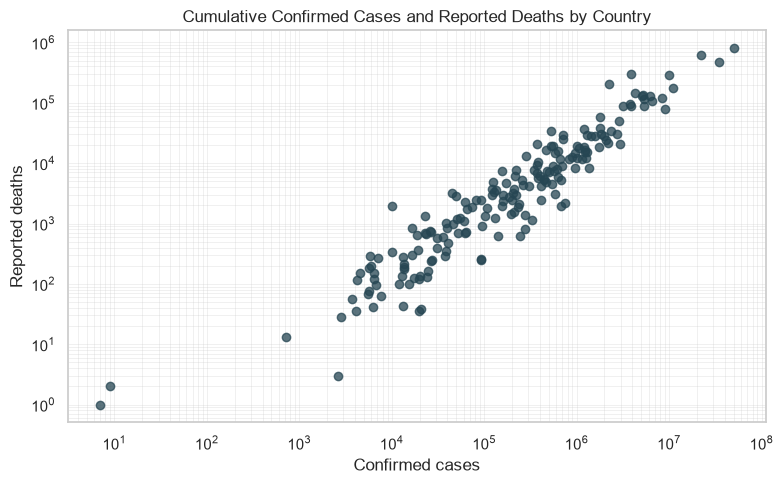

In [28]:
scatter_data = country_summary[
    (country_summary["confirmed"] > 0) &
    (country_summary["deaths"] > 0)
].copy()

plt.figure(figsize=(8, 5))

plt.scatter(
    scatter_data["confirmed"],
    scatter_data["deaths"],
    color=DARK_TEAL,
    alpha=0.75
)

plt.title("Cumulative Confirmed Cases and Reported Deaths by Country")
plt.xlabel("Confirmed cases")
plt.ylabel("Reported deaths")
plt.xscale("log")
plt.yscale("log")
plt.grid(True, which="both", linewidth=0.5, alpha=0.4)
plt.tight_layout()
plt.show()


### Activity 7 — Change the visual emphasis

The first Matplotlib chart showed confirmed cases. This try-out shifts the visual story to reported deaths.

**Tip:** Same chart structure, different variable and colour meaning.

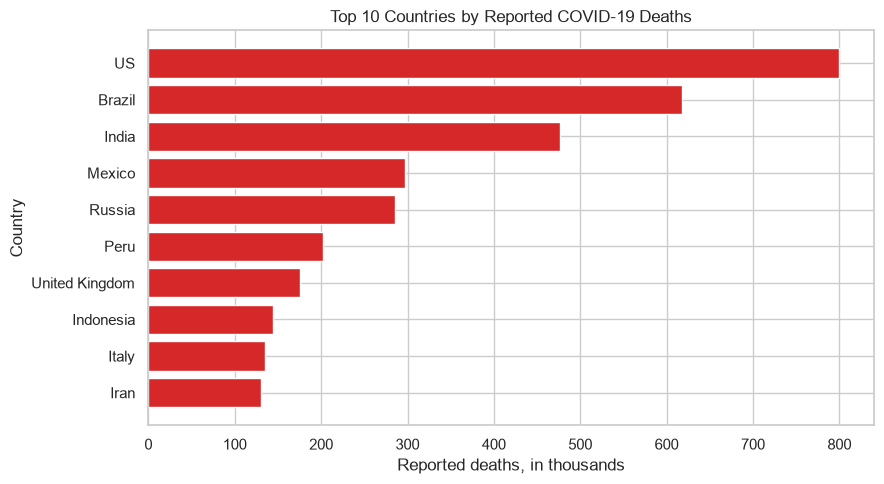

Highest reported deaths in this view:


,country,deaths
186,US,800046


In [29]:
# Try-out your code here in this cell

# Activity 7 Try out

death_plot_data = (
    country_summary
    .sort_values("deaths", ascending=False)
    .head(TOP_N)
    .sort_values("deaths", ascending=True)
    .copy()
)

death_plot_data["deaths_thousands"] = death_plot_data["deaths"] / 1_000

plt.figure(figsize=(9, 5))

plt.barh(
    death_plot_data["country"],
    death_plot_data["deaths_thousands"],
    color=ALERT_RED
)

plt.title(f"Top {TOP_N} Countries by Reported COVID-19 Deaths")
plt.xlabel("Reported deaths, in thousands")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

print("Highest reported deaths in this view:")
display(death_plot_data.tail(1)[["country", "deaths"]])



## Seaborn figures

Seaborn is useful for statistical-style summaries and cleaner default graphics.


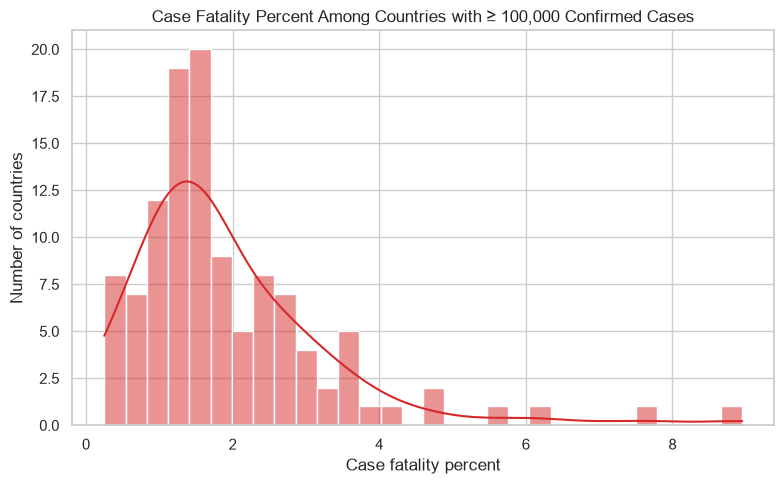

In [30]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=rate_comparison_table,
    x="case_fatality_percent",
    bins=30,
    kde=True,
    color=ALERT_RED
)

plt.title(f"Case Fatality Percent Among Countries with ≥ {MIN_CONFIRMED_FOR_RATE:,} Confirmed Cases")
plt.xlabel("Case fatality percent")
plt.ylabel("Number of countries")
plt.tight_layout()
plt.show()


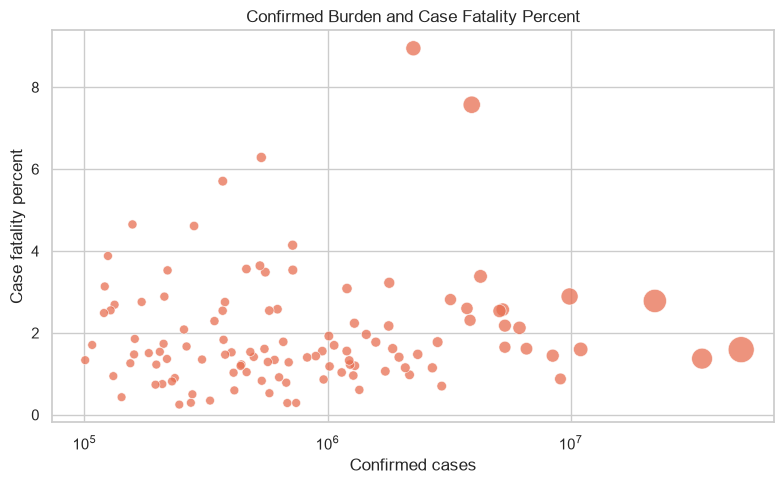

In [31]:
bubble_data = country_summary[
    (country_summary["confirmed"] >= MIN_CONFIRMED_FOR_RATE) &
    (country_summary["case_fatality_percent"].notna()) &
    (country_summary["deaths"] > 0)
].copy()

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=bubble_data,
    x="confirmed",
    y="case_fatality_percent",
    size="deaths",
    sizes=(40, 350),
    color=CORAL,
    alpha=0.75,
    legend=False
)

plt.title("Confirmed Burden and Case Fatality Percent")
plt.xlabel("Confirmed cases")
plt.ylabel("Case fatality percent")
plt.xscale("log")
plt.tight_layout()
plt.show()


### Activity 8 — Compare groups with Seaborn

Seaborn is useful when the question is about distribution, not only totals.

**Tip:** The boxplot compares case fatality percent across burden classes; it does not prove risk or causation.

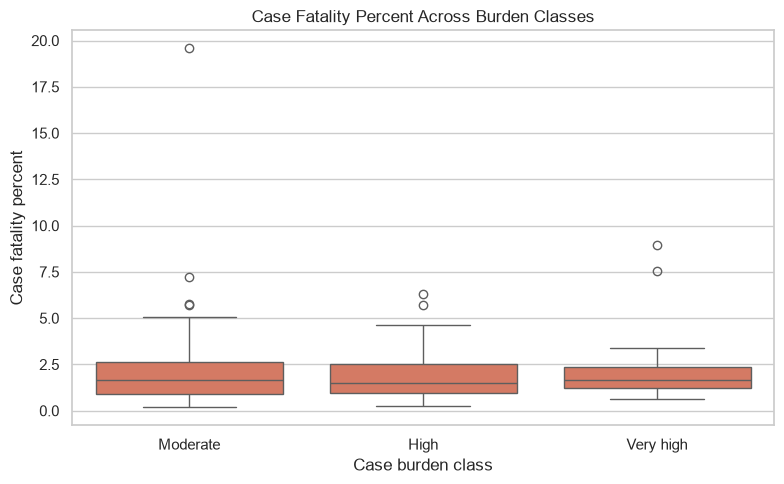

Median case fatality percent by burden class:
case_burden_class
Moderate     1.63
High         1.49
Very high    1.63
Name: case_fatality_percent, dtype: float64


In [32]:
# Try-out your code here in this cell
# Activity 8 Try out

seaborn_activity_data = country_summary[
    (country_summary["confirmed"] >= 10_000) &
    (country_summary["case_fatality_percent"].notna())
].copy()

burden_order = ["Moderate", "High", "Very high"]
burden_order = [
    label for label in burden_order
    if label in seaborn_activity_data["case_burden_class"].unique()
]

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=seaborn_activity_data,
    x="case_burden_class",
    y="case_fatality_percent",
    order=burden_order,
    color=CORAL
)

plt.title("Case Fatality Percent Across Burden Classes")
plt.xlabel("Case burden class")
plt.ylabel("Case fatality percent")
plt.tight_layout()
plt.show()

median_by_class = (
    seaborn_activity_data
    .groupby("case_burden_class")["case_fatality_percent"]
    .median()
    .reindex(burden_order)
    .round(2)
)

print("Median case fatality percent by burden class:")
print(median_by_class)

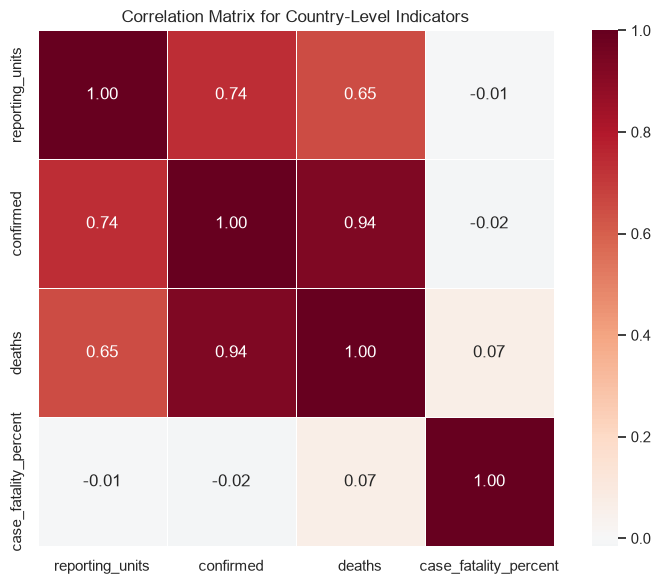

In [33]:
numeric_for_corr = [
    "reporting_units",
    "confirmed",
    "deaths",
    "recovered",
    "active",
    "active_share_percent",
    "case_fatality_percent"
]

numeric_for_corr = [
    column for column in numeric_for_corr
    if column in country_summary.columns
]

corr_data = country_summary[numeric_for_corr].copy()

# Remove columns that are fully missing or have no variation.
corr_data = corr_data.dropna(axis=1, how="all")
corr_data = corr_data.loc[:, corr_data.nunique(dropna=True) > 1]

correlation_matrix = corr_data.corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap=DIVERGING_CMAP,
    center=0,
    square=True,
    linewidths=0.5
)

plt.title("Correlation Matrix for Country-Level Indicators")
plt.tight_layout()
plt.show()


### Activity 9 — Create and Read a heatmap

A correlation heatmap is useful only when the relationship can be explained carefully.

**Tip:** Identify one strong positive relationship and avoid causal language.

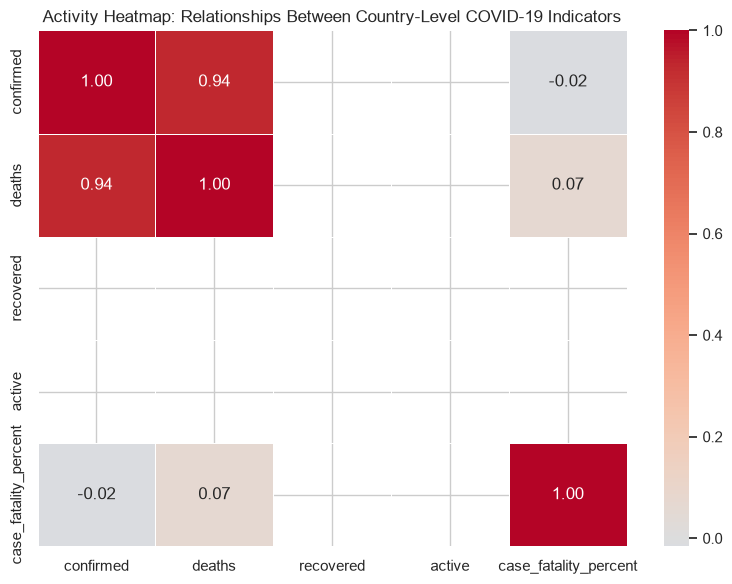

Strongest positive relationship in this activity heatmap:
confirmed  deaths    0.935758
dtype: float64

Scientific interpretation:
This heatmap shows descriptive relationships between variables.
It does not prove that one variable causes another.


In [34]:
# Try-out your code here in this cell
# Step 1: Select numeric columns connected to the country-level dataset
activity_heatmap_columns = [
    "confirmed",
    "deaths",
    "recovered",
    "active",
    "case_fatality_percent",
    "recovery_percent",
    "active_percent"
]

# Step 2: Keep only columns that are actually present in the dataset
activity_heatmap_columns = [
    col for col in activity_heatmap_columns
    if col in country_summary.columns
]

# Step 3: Create a smaller dataset for the heatmap
activity_heatmap_data = country_summary[activity_heatmap_columns].copy()

# Step 4: Calculate the correlation matrix
activity_correlation_matrix = activity_heatmap_data.corr()

# Step 5: Plot the heatmap
plt.figure(figsize=(8, 6))

sns.heatmap(
    activity_correlation_matrix,
    annot=True,
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    fmt=".2f"
)

plt.title("Activity Heatmap: Relationships Between Country-Level COVID-19 Indicators")
plt.tight_layout()
plt.show()

# Step 6: Identify the strongest positive relationship, excluding self-correlation
upper_triangle = activity_correlation_matrix.where(
    np.triu(np.ones(activity_correlation_matrix.shape), k=1).astype(bool)
)

strongest_positive = (
    upper_triangle
    .stack()
    .sort_values(ascending=False)
    .head(1)
)

print("Strongest positive relationship in this activity heatmap:")
print(strongest_positive)

print("\nScientific interpretation:")
print("This heatmap shows descriptive relationships between variables.")
print("It does not prove that one variable causes another.")


## Mini case study

Build a review table. Confirmed counts are reporting-dependent, and case fatality percent is affected by testing, reporting, age structure, health-system access, and time lag.


In [35]:
# Mini Case Study: Create a country-level review table

# Step 1: Keep only countries with enough confirmed cases for fairer rate comparison
review_base = country_summary[
    (country_summary["confirmed"] >= MIN_CONFIRMED_FOR_RATE)
    & (country_summary["case_fatality_percent"].notna())
].copy()

# Step 2: Use the median case fatality percent as a simple comparison cutoff
rate_cutoff = review_base["case_fatality_percent"].median()

# Step 3: Select countries with confirmed cases above the minimum threshold
# and case fatality percent at or above the comparison cutoff
review_table = (
    review_base[
        review_base["case_fatality_percent"] >= rate_cutoff
    ]
    .sort_values(
        ["confirmed", "case_fatality_percent"],
        ascending=[False, False]
    )
    .reset_index(drop=True)
)

# Step 4: Keep only the most relevant columns for interpretation
review_table = review_table[
    [
        "country",
        "reporting_units",
        "confirmed",
        "deaths",
        "case_fatality_percent",
        "active_share_percent",
        "case_burden_class"
    ]
]

print("Mini case study: Country-level review table")
print("Minimum confirmed cases used:", f"{MIN_CONFIRMED_FOR_RATE:,}")
print("Median case fatality percent cutoff:", round(rate_cutoff, 2))

display(review_table.head(15))


Mini case study: Country-level review table
Minimum confirmed cases used: 100,000
Median case fatality percent cutoff: 1.56


,country,reporting_units,confirmed,deaths,case_fatality_percent,active_share_percent,case_burden_class
0,US,3279,50289495,800046,1.590881,0.0,Very high
1,Brazil,27,22200629,617254,2.780345,0.0,Very high
2,United Kingdom,19,10995158,175638,1.597412,0.0,Very high
3,Russia,83,9899139,286023,2.889372,0.0,Very high
4,Germany,17,6582303,106227,1.613827,0.0,Very high
5,Iran,1,6160303,130831,2.123775,0.0,Very high
6,Argentina,1,5366522,116826,2.176941,0.0,Very high
7,Spain,20,5366128,88542,1.650017,0.0,Very high
8,Italy,21,5258886,135049,2.568015,0.0,Very high
9,Colombia,34,5097680,129205,2.534584,0.0,Very high


In [36]:
# In the next cell you can try out

# Mini Case Study: Summarize one selected country

selected_country_summary = country_summary[
    country_summary["country"]
    .astype(str)
    .str.casefold()
    .eq(COUNTRY_TO_VIEW.casefold())
].copy()

if selected_country_summary.empty:
    print("Selected country not found. Change COUNTRY_TO_VIEW and rerun.")
else:
    row = selected_country_summary.iloc[0]

    print("Selected country summary")
    print("------------------------")
    print("Country:", row["country"])
    print("Reporting units:", int(row["reporting_units"]))
    print("Confirmed cases:", f"{int(row['confirmed']):,}")
    print("Reported deaths:", f"{int(row['deaths']):,}")
    print("Case fatality percent:", round(row["case_fatality_percent"], 2))
    print("Active share percent:", round(row["active_share_percent"], 2))
    print("Burden class:", row["case_burden_class"])

    print("\nInterpretation:")
    print("This is a descriptive summary based on reported data.")
    print("It should be used for review and discussion, not as direct proof of risk or causation.")


Selected country summary
------------------------
Country: India
Reporting units: 37
Confirmed cases: 34,710,628
Reported deaths: 476,135
Case fatality percent: 1.37
Active share percent: 0.0
Burden class: Very high

Interpretation:
This is a descriptive summary based on reported data.
It should be used for review and discussion, not as direct proof of risk or causation.


## Save outputs to Google Drive

Colab runtime files are temporary. Mount Google Drive before exporting so the final tables remain available after the session.


In [37]:
# from google.colab import drive
# from pathlib import Path

# drive.mount("/content/drive")

# export_dir = Path("/content/drive/MyDrive/Python_Colab_Primer_Exports")
# export_dir.mkdir(parents=True, exist_ok=True)

# print("Google Drive export folder is ready:")
# print(export_dir)
import os
export_dir = "./export_dir"
os.makedirs(export_dir, exist_ok=True)


## Export research-ready outputs

The final step is not only analysis; it is leaving behind clean files that another person can inspect.


In [39]:
analysis_df.to_csv(f"{export_dir}/covid_location_level_cleaned.csv", index=False)
country_summary.to_csv(f"{export_dir}/covid_country_level_summary.csv", index=False)
#priority_table.to_csv(f"{export_dir}/covid_priority_review_table.csv", index=False)

print("Files saved to Google Drive:")

print(f"{export_dir}/covid_location_level_cleaned.csv")
print(f"{export_dir}/covid_country_level_summary.csv")
#print(f"{export_dir}/covid_priority_review_table.csv")


Files saved to Google Drive:
./export_dir/covid_location_level_cleaned.csv
./export_dir/covid_country_level_summary.csv


### Final activity — Make the workflow yours

A reproducible notebook becomes powerful when one small change can update the whole workflow.

**Tip:** Change one focus value, rerun the relevant section, and check whether the final output still makes sense.